# 🔄 ChurnZero — Customer Churn Prediction Pipeline

**Model:** XGBoost with Target Encoding  
**Primary Metric:** PR-AUC (Precision-Recall AUC)  
**Secondary Metric:** F1-Score on Positive (Churn) Class  
**Business Cost:** FN = ₹40,000 (missed churner) | FP = ₹500 (unnecessary retention spend)

---

## 📋 Grading Criteria

| Component | Weight | Notes |
|---|---|---|
| **Model Performance** | 40% | Primary: PR-AUC on held-out test. Secondary: F1 on positive class. FN cost ₹40,000, FP cost ₹500. |
| **Presentation Quality** | 25% | Clarity for exec audience, depth of insight, business framing. |
| **Methodology & Rigour** | 20% | Feature engineering decisions and no data leakage. |
| **Code Quality** | 15% | Reproducibility, readability, organisation, and comments. |

---

## 📁 Pipeline Overview

```
1. Data Loading
2. Drop Leaky / Redundant Columns
3. Split Features & Target
4. Identify Column Types & Impute Missing Values
5. Build Preprocessor + XGBoost Pipeline
6. 5-Fold Stratified Cross-Validation
7. Optimal Decision Threshold Search (F1-Maximising)
8. Full Evaluation Report + Business Cost
9. Retrain on 100% of Training Data
10. SHAP Explainability & Feature Importance Plots
11. Score Test File → Export Predictions

## 📦 Section 0 — Imports & Configuration

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import logging
from pathlib import Path

# ── Third-Party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ── Logging setup ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## ⚙️ Section 1 — Constants & Business Parameters

In [2]:
TRAIN_PATH = "ChurnZero_dataset_v1.csv"
TEST_PATH  = "ChurnZero_test_v1.csv"
TARGET_COL = "churn"

# Columns explicitly excluded to prevent data leakage or redundancy.
# ⚠️  Do NOT re-introduce these under any circumstances.
LEAKY_COLS = [
    # --------------------------------------------------------
    # 1. Identifiers & Leaky Features (Real-world failures)
    # --------------------------------------------------------
    "customer_id",
    "balance_decline_percentage",
    "unresolved_complaint_count",
    "account_inactive_days",
    "retention_offer_accepted",

    # --------------------------------------------------------
    # 2. Redundant Aggregations & Binned Data
    # --------------------------------------------------------
    "income_band",
    "income_category",
    "monthly_income_estimate",
    "total_digital_logins",

    # --------------------------------------------------------
    # 3. Zero Variance (Dead weight)
    # --------------------------------------------------------
    "mobile_banking_active_flag",
    "credit_card_flag",

    # --------------------------------------------------------
    # 4. High missingness (>50%), no meaningful correlation
    # --------------------------------------------------------
    "app_rating_given",

    # --------------------------------------------------------
    # 5. Multicollinear 'Clones' (correlation > 0.95)
    # --------------------------------------------------------
    "monthly_transaction_value",   # Keep: total_trans_amt
    "monthly_transaction_count",   # Keep: total_trans_count
    "emi_amount",                  # Keep: loan_outstanding_amount
    "credit_utilization_3m_avg",   # Keep: credit_utilization_ratio
    "credit_utilization_6m_avg",   # Keep: credit_utilization_ratio
    "avg_quarterly_balance",       # Keep: avg_monthly_balance & current_balance
    "avg_open_to_buy",             # Keep: credit_card_limit
]

# Business cost matrix (in INR ₹)
FN_COST = 40_000   # False Negative: missed churner → lost customer lifetime value
FP_COST = 500      # False Positive: unnecessary retention spend

# Decision threshold
DECISION_THRESHOLD = 0.5

# Cross-validation
N_FOLDS = 5

# Reproducibility
RANDOM_STATE = 42

print(f"✅ Constants set. FN Cost = ₹{FN_COST:,} | FP Cost = ₹{FP_COST:,} | CV Folds = {N_FOLDS}")

✅ Constants set. FN Cost = ₹40,000 | FP Cost = ₹500 | CV Folds = 5


## 📂 Section 2 — Data Loading

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """
    Load a CSV file and return a DataFrame.
    Raises FileNotFoundError with a helpful message if the path is wrong.
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(
            f"Data file not found at '{path}'. "
            "Please verify the path and re-run."
        )
    df = pd.read_csv(p)
    log.info("Loaded '%s' → shape %s", p.name, df.shape)
    return df

## 🧹 Section 3 — Pre-processing Functions

In [4]:
def drop_leaky_columns(df: pd.DataFrame, target_col: str = TARGET_COL) -> pd.DataFrame:
    """
    Drop columns that cause data leakage, are redundant, or are identifiers.
    Only drops columns that actually exist — safe for both train and test files.
    """
    cols_to_drop = [c for c in LEAKY_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    log.info("Dropped %d leaky/redundant columns: %s", len(cols_to_drop), cols_to_drop)
    return df


def identify_column_types(df: pd.DataFrame) -> tuple[list, list]:
    """
    Separate features into categorical (string/object) and numeric columns.
    Returns (categorical_cols, numeric_cols).
    """
    cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    log.info("Feature types → %d numeric, %d categorical", len(num_cols), len(cat_cols))
    return cat_cols, num_cols


def handle_missing_values(df: pd.DataFrame, cat_cols: list, num_cols: list) -> pd.DataFrame:
    """
    Impute missing values conservatively:
      - Numeric     → median (robust to skew)
      - Categorical → mode  (most frequent category)
    """
    for col in num_cols:
        if df[col].isnull().any():
            fill_val = df[col].median()
            df[col] = df[col].fillna(fill_val)
            log.info("Imputed numeric '%s' → median=%.4f", col, fill_val)

    for col in cat_cols:
        if df[col].isnull().any():
            fill_val = df[col].mode()[0]
            df[col] = df[col].fillna(fill_val)
            log.info("Imputed categorical '%s' → mode='%s'", col, fill_val)

    return df


print("✅ Pre-processing functions defined.")

✅ Pre-processing functions defined.


---
## 🔧 Section 4 — Feature Engineering & Model Pipeline

**Encoding Strategy:** Target Encoding for categoricals (vs One-Hot) — avoids dimensionality explosion and naturally handles high-cardinality features. Fitted independently inside each CV fold to prevent leakage.

**XGBoost Hyperparameter Rationale:**

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 500 | High enough for convergence; LR guards against overfit |
| `learning_rate` | 0.05 | Low LR + more trees → better generalisation |
| `max_depth` | 6 | Captures complex interactions |
| `subsample` | 0.8 | Row sampling → reduces variance |
| `colsample_bytree` | 0.8 | Column sampling per tree |
| `min_child_weight` | 5 | Conservative splits (avoids overfit) |
| `gamma` | 1.0 | Minimum gain required to split a node |
| `scale_pos_weight` | computed | Corrects class imbalance |
| `eval_metric` | aucpr | Directly optimises PR-AUC during training |

In [5]:
def build_preprocessor(cat_cols: list, num_cols: list) -> ColumnTransformer:
    """
    Build a ColumnTransformer that applies:
      - Categorical : Mode imputation → Target Encoding
      - Numeric     : Median imputation
    """
    # 1. Pipeline for Categorical Features
    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_enc", TargetEncoder(
            smoothing=1.0,
            handle_unknown="value"
        ))
    ])

    # 2. Pipeline for Numeric Features
    num_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # 3. Combine into ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_pipeline, cat_cols),
            ("num", num_pipeline, num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor


def build_pipeline(preprocessor: ColumnTransformer, scale_pos_weight: float) -> Pipeline:
    """
    Build the end-to-end sklearn Pipeline: Preprocessor → XGBClassifier
    scale_pos_weight = count(negatives) / count(positives) — handles class imbalance.
    """
    xgb = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=1.0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb),
    ])
    return pipeline


print("✅ Pipeline builder functions defined.")

✅ Pipeline builder functions defined.


## 🎯 Section 5 — Threshold Optimisation

> On imbalanced datasets, the default 0.5 threshold is rarely optimal.  
> We sweep [0.10 → 0.90] and pick the threshold that maximises **F1-Score on churners**.

In [6]:
def find_optimal_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    """
    Find the classification threshold that maximises F1-Score on the positive
    class (churners). Sweeps thresholds in [0.1, 0.9] and picks the best.
    """
    best_thresh, best_f1 = 0.5, 0.0
    for thresh in np.arange(0.10, 0.91, 0.01):
        y_pred = (y_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    log.info("Optimal threshold = %.2f  (F1 = %.4f)", best_thresh, best_f1)
    return round(float(best_thresh), 2)


print("✅ Threshold optimisation function defined.")

✅ Threshold optimisation function defined.


## 📊 Section 6 — Evaluation Functions

**Business Cost Framing:**
- A **False Negative** (missed churner) costs ₹40,000 — the customer leaves unretained.
- A **False Positive** (wrongly flagged loyal customer) costs ₹500 — wasted retention spend.
- This 80:1 cost asymmetry means **recall on churners is far more important than precision**.

In [7]:
def compute_business_cost(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute the total financial cost of model errors using the cost matrix:
        - False Negative (FN): ₹40,000 per missed churner
        - False Positive (FP): ₹500  per incorrectly flagged loyal customer
    Returns a dict with FN count, FP count, and total cost.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fn * FN_COST) + (fp * FP_COST)

    result = {
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
        "FN_cost_INR": fn * FN_COST,
        "FP_cost_INR": fp * FP_COST,
        "total_cost_INR": total_cost,
    }
    return result


def print_evaluation_report(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    label: str = "Cross-Validated",
) -> None:
    """
    Print a full evaluation report:
        1. PR-AUC and ROC-AUC
        2. F1-Score on positive class
        3. Classification report (precision, recall, F1 per class)
        4. Business Cost Matrix breakdown
    """
    y_pred = (y_proba >= threshold).astype(int)

    pr_auc  = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    f1      = f1_score(y_true, y_pred, pos_label=1)
    cost    = compute_business_cost(y_true, y_pred)

    divider = "═" * 60
    print(f"\n{divider}")
    print(f"  EVALUATION REPORT  [{label}]  (threshold={threshold:.2f})")
    print(divider)
    print(f"  PRIMARY   → PR-AUC (Avg Precision) : {pr_auc:.4f}")
    print(f"  SECONDARY → ROC-AUC                : {roc_auc:.4f}")
    print(f"  SECONDARY → F1-Score (Churners)    : {f1:.4f}")
    print()
    print("  CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=["Retained", "Churned"]))
    print()
    print("  BUSINESS COST MATRIX:")
    print(f"    True  Positives (correctly caught churners) : {cost['TP']:>6,}")
    print(f"    False Negatives (missed churners)           : {cost['FN']:>6,}  × ₹{FN_COST:,} = ₹{cost['FN_cost_INR']:>12,}")
    print(f"    False Positives (wrongly flagged loyal)     : {cost['FP']:>6,}  × ₹{FP_COST:,}   = ₹{cost['FP_cost_INR']:>12,}")
    print(f"    ─────────────────────────────────────────────────────")
    print(f"    TOTAL ESTIMATED COST                        :          ₹{cost['total_cost_INR']:>12,}")
    print(divider)


print("✅ Evaluation functions defined.")

✅ Evaluation functions defined.



---
## 📈 Section 7 — Visualisation Functions

Includes: Confusion Matrix, Correlation Heatmap, PR Curve, SHAP Summary, SHAP Bar Plot, XGBoost Native Importance.

In [8]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    label: str = "GAXGB",
    output_path: str = "confusion_matrix.png",
) -> None:
    """
    Plot and display a styled confusion matrix with [TP, FN], [FP, TN] sequence.
    """
    y_pred = (y_proba >= threshold).astype(int)
    
    # Force the sequence: [1, 0] -> [[TP, FN], [FP, TN]]
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor="white",
        # Labels updated to reflect the [1, 0] order
        xticklabels=["yes", "no"],
        yticklabels=["yes", "no"],
        annot_kws={"size": 18, "weight": "bold", "color": "white"},
        ax=ax,
        vmin=0,
    )

    # Fix annotation text colour
    max_val = cm.max()
    for text, val in zip(ax.texts, cm.flatten()):
        text.set_color("white" if val > max_val * 0.4 else "#333333")
        text.set_fontsize(16)

    ax.set_title(f"{label} Confusion Matrix", fontsize=15, pad=14, fontweight="bold")
    ax.set_xlabel("Predicted Class", fontsize=12, labelpad=10)
    ax.set_ylabel("True Class", fontsize=12, labelpad=10)
    ax.tick_params(axis="both", which="both", length=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    # Updated print statement to match the new matrix structure
    print(f"\n📊 Confusion Matrix saved → '{output_path}'")
    print(f"   TP={cm[0,0]:,}  FN={cm[0,1]:,}  FP={cm[1,0]:,}  TN={cm[1,1]:,}")

In [9]:
def plot_correlation_heatmap(
    df: pd.DataFrame,
    output_path: str = "correlation_heatmap.png",
) -> None:
    """
    Plot a correlation heatmap of all numeric features in the DataFrame,
    styled to match the blue-green-yellow palette shown in the competition brief.

    Useful for identifying multicollinear features before modelling.
    """
    numeric_df = df.select_dtypes(include="number")
    corr = numeric_df.corr()

    # Dynamically scale figure height with number of features
    n = len(corr)
    fig_size = max(10, n * 0.65)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

    mask = np.zeros_like(corr, dtype=bool)   # no masking — show full matrix

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",           # matches the blue-teal-yellow scheme in brief
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.3,
        linecolor="white",
        annot_kws={"size": 7},
        ax=ax,
        square=True,
        cbar_kws={"shrink": 0.75},
    )

    ax.set_title("Correlation between variables", fontsize=14, pad=14, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n🔥 Correlation heatmap saved → '{output_path}'")


print("✅ Correlation heatmap function defined.")

✅ Correlation heatmap function defined.


In [10]:
def generate_shap_summary(
    pipeline: Pipeline,
    X: pd.DataFrame,
    feature_names: list,
    output_path: str = "shap_summary_plot.png",
    max_display: int = 20,
) -> None:
    """
    Generate a SHAP beeswarm summary plot — top features ranked by mean |SHAP value|,
    showing direction and magnitude of each feature's impact on churn prediction.
    Leaky features are already removed; these are the TRUE drivers of churn.
    """
    log.info("Computing SHAP values (this may take ~30s for large datasets)...")

    xgb_model = pipeline.named_steps["classifier"]
    X_transformed = pipeline.named_steps["preprocessor"].transform(X)

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_transformed)
    shap_df     = pd.DataFrame(X_transformed, columns=feature_names)

    plt.figure(figsize=(12, 12))
    shap.summary_plot(
        shap_values, shap_df,
        max_display=max_display,
        show=False,
        plot_type="dot",
    )
    plt.title(
        f"SHAP Summary — Top {max_display} True Churn Drivers\n"
        "(Leaky features removed; values are raw & un-binned)",
        fontsize=13, pad=14,
    )
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info("SHAP summary plot saved → '%s'", output_path)


def generate_pr_curve(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    pr_auc: float,
    output_path: str = "pr_curve.png",
) -> None:
    """Display and save the Precision-Recall curve."""
    fig, ax = plt.subplots(figsize=(8, 6))
    PrecisionRecallDisplay.from_predictions(
        y_true, y_proba,
        name=f"XGBoost (PR-AUC = {pr_auc:.4f})",
        ax=ax,
    )
    ax.set_title("Precision-Recall Curve — Churn Prediction", fontsize=13)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info("PR Curve saved → '%s'", output_path)


def generate_shap_bar_plot(
    pipeline: Pipeline,
    X: pd.DataFrame,
    feature_names: list,
    output_path: str = "shap_importance_ranking.png",
    max_display: int = 20,
) -> None:
    """Generate a SHAP bar plot ranking features by mean absolute SHAP value."""
    log.info("Computing SHAP bar plot ranking...")
    xgb_model     = pipeline.named_steps["classifier"]
    X_transformed = pipeline.named_steps["preprocessor"].transform(X)
    explainer     = shap.TreeExplainer(xgb_model)
    shap_values   = explainer.shap_values(X_transformed)
    shap_df       = pd.DataFrame(X_transformed, columns=feature_names)

    plt.figure(figsize=(10, 10))
    shap.summary_plot(
        shap_values, shap_df,
        max_display=max_display,
        plot_type="bar",
        show=False,
        color="#e74c3c"
    )
    plt.title(f"SHAP Feature Importance Ranking — Top {max_display}", fontsize=13, pad=14)
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=9)
    plt.gcf().subplots_adjust(bottom=0.15)
    plt.savefig(output_path, dpi=150, bbox_inches="tight", pad_inches=0.2)
    plt.show()
    log.info("SHAP bar ranking plot saved → '%s'", output_path)


def generate_xgb_importance_plot(
    pipeline: Pipeline,
    feature_names: list,
    output_path: str = "xgb_feature_importance.png",
    max_display: int = 20
) -> None:
    """Generate a horizontal bar chart of XGBoost built-in feature importances (gain)."""
    log.info("Computing XGBoost native feature importance order...")
    xgb_model   = pipeline.named_steps["classifier"]
    importances = xgb_model.feature_importances_

    imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    imp_df = imp_df.sort_values(by="Importance", ascending=True).tail(max_display)

    plt.figure(figsize=(10, 8))
    plt.barh(imp_df["Feature"], imp_df["Importance"], color="#3498db", edgecolor="black")
    plt.xlabel("XGBoost Built-in Importance (Gain)", fontsize=11)
    plt.title(f"XGBoost Feature Importance Order (Top {max_display})", fontsize=13)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info("XGBoost feature importance plot saved → '%s'", output_path)


print("✅ All visualisation functions defined.")

✅ All visualisation functions defined.


---
## 🔍 Section 8 — Exploratory Data Analysis (EDA)

We load the training data and visualise the **correlation heatmap** before modelling.  
This informed which columns to drop as multicollinear (e.g., `avg_open_to_buy`, `credit_utilization_3m_avg`).

In [11]:
# ── Step 1: Load Training Data ────────────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 1: Loading training data")
df_train = load_data(TRAIN_PATH)

print(f"\n📋 Dataset shape: {df_train.shape}")
print(f"\nColumn overview:")
df_train.info()

18:25:16 | INFO | ============================================================
18:25:16 | INFO | STEP 1: Loading training data
18:25:16 | INFO | Loaded 'ChurnZero_dataset_v1.csv' → shape (8101, 98)



📋 Dataset shape: (8101, 98)

Column overview:
<class 'pandas.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 98 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   customer_id                             8101 non-null   int64  
 1   churn                                   8101 non-null   int64  
 2   age                                     8101 non-null   int64  
 3   gender                                  8101 non-null   str    
 4   marital_status                          8101 non-null   str    
 5   education_level                         8101 non-null   str    
 6   dependent_count                         8101 non-null   int64  
 7   occupation_type                         8101 non-null   str    
 8   annual_income                           8101 non-null   int64  
 9   income_band                             8101 non-null   str    
 10  income_category         

In [12]:
# Quick summary statistics
print("\n📊 Target class distribution:")
churn_counts = df_train[TARGET_COL].value_counts()
churn_pct    = df_train[TARGET_COL].value_counts(normalize=True) * 100
print(pd.DataFrame({"Count": churn_counts, "Percentage": churn_pct.round(1)}))

print("\n📈 Numeric feature summary:")
df_train.describe().T


📊 Target class distribution:
       Count  Percentage
churn                   
0       6799        83.9
1       1302        16.1

📈 Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
customer_id,8101.0,137051.000000,2338.701598,133001.0,135026.000,137051.0000,139076.000,141101.000
churn,8101.0,0.160721,0.367296,0.0,0.000,0.0000,0.000,1.000
age,8101.0,46.390199,7.985385,26.0,41.000,46.0000,52.000,73.000
dependent_count,8101.0,2.349093,1.297993,0.0,1.000,2.0000,3.000,5.000
annual_income,8101.0,60052.874583,35422.472020,18000.0,31813.000,51592.0000,76910.000,241318.000
...,...,...,...,...,...,...,...,...
credit_utilization_6m_avg,8101.0,0.281485,0.215617,0.0,0.105,0.2180,0.450,0.935
avg_quarterly_balance,8101.0,45642.588940,39075.635887,2781.0,20729.000,34888.0000,57919.000,501402.000
total_digital_logins,8101.0,28.060363,6.394283,6.0,24.000,28.0000,32.000,50.000
debt_to_income_ratio,8101.0,0.415710,0.702155,0.0,0.000,0.1633,0.519,5.000


🔥 Generating Correlation Heatmap...



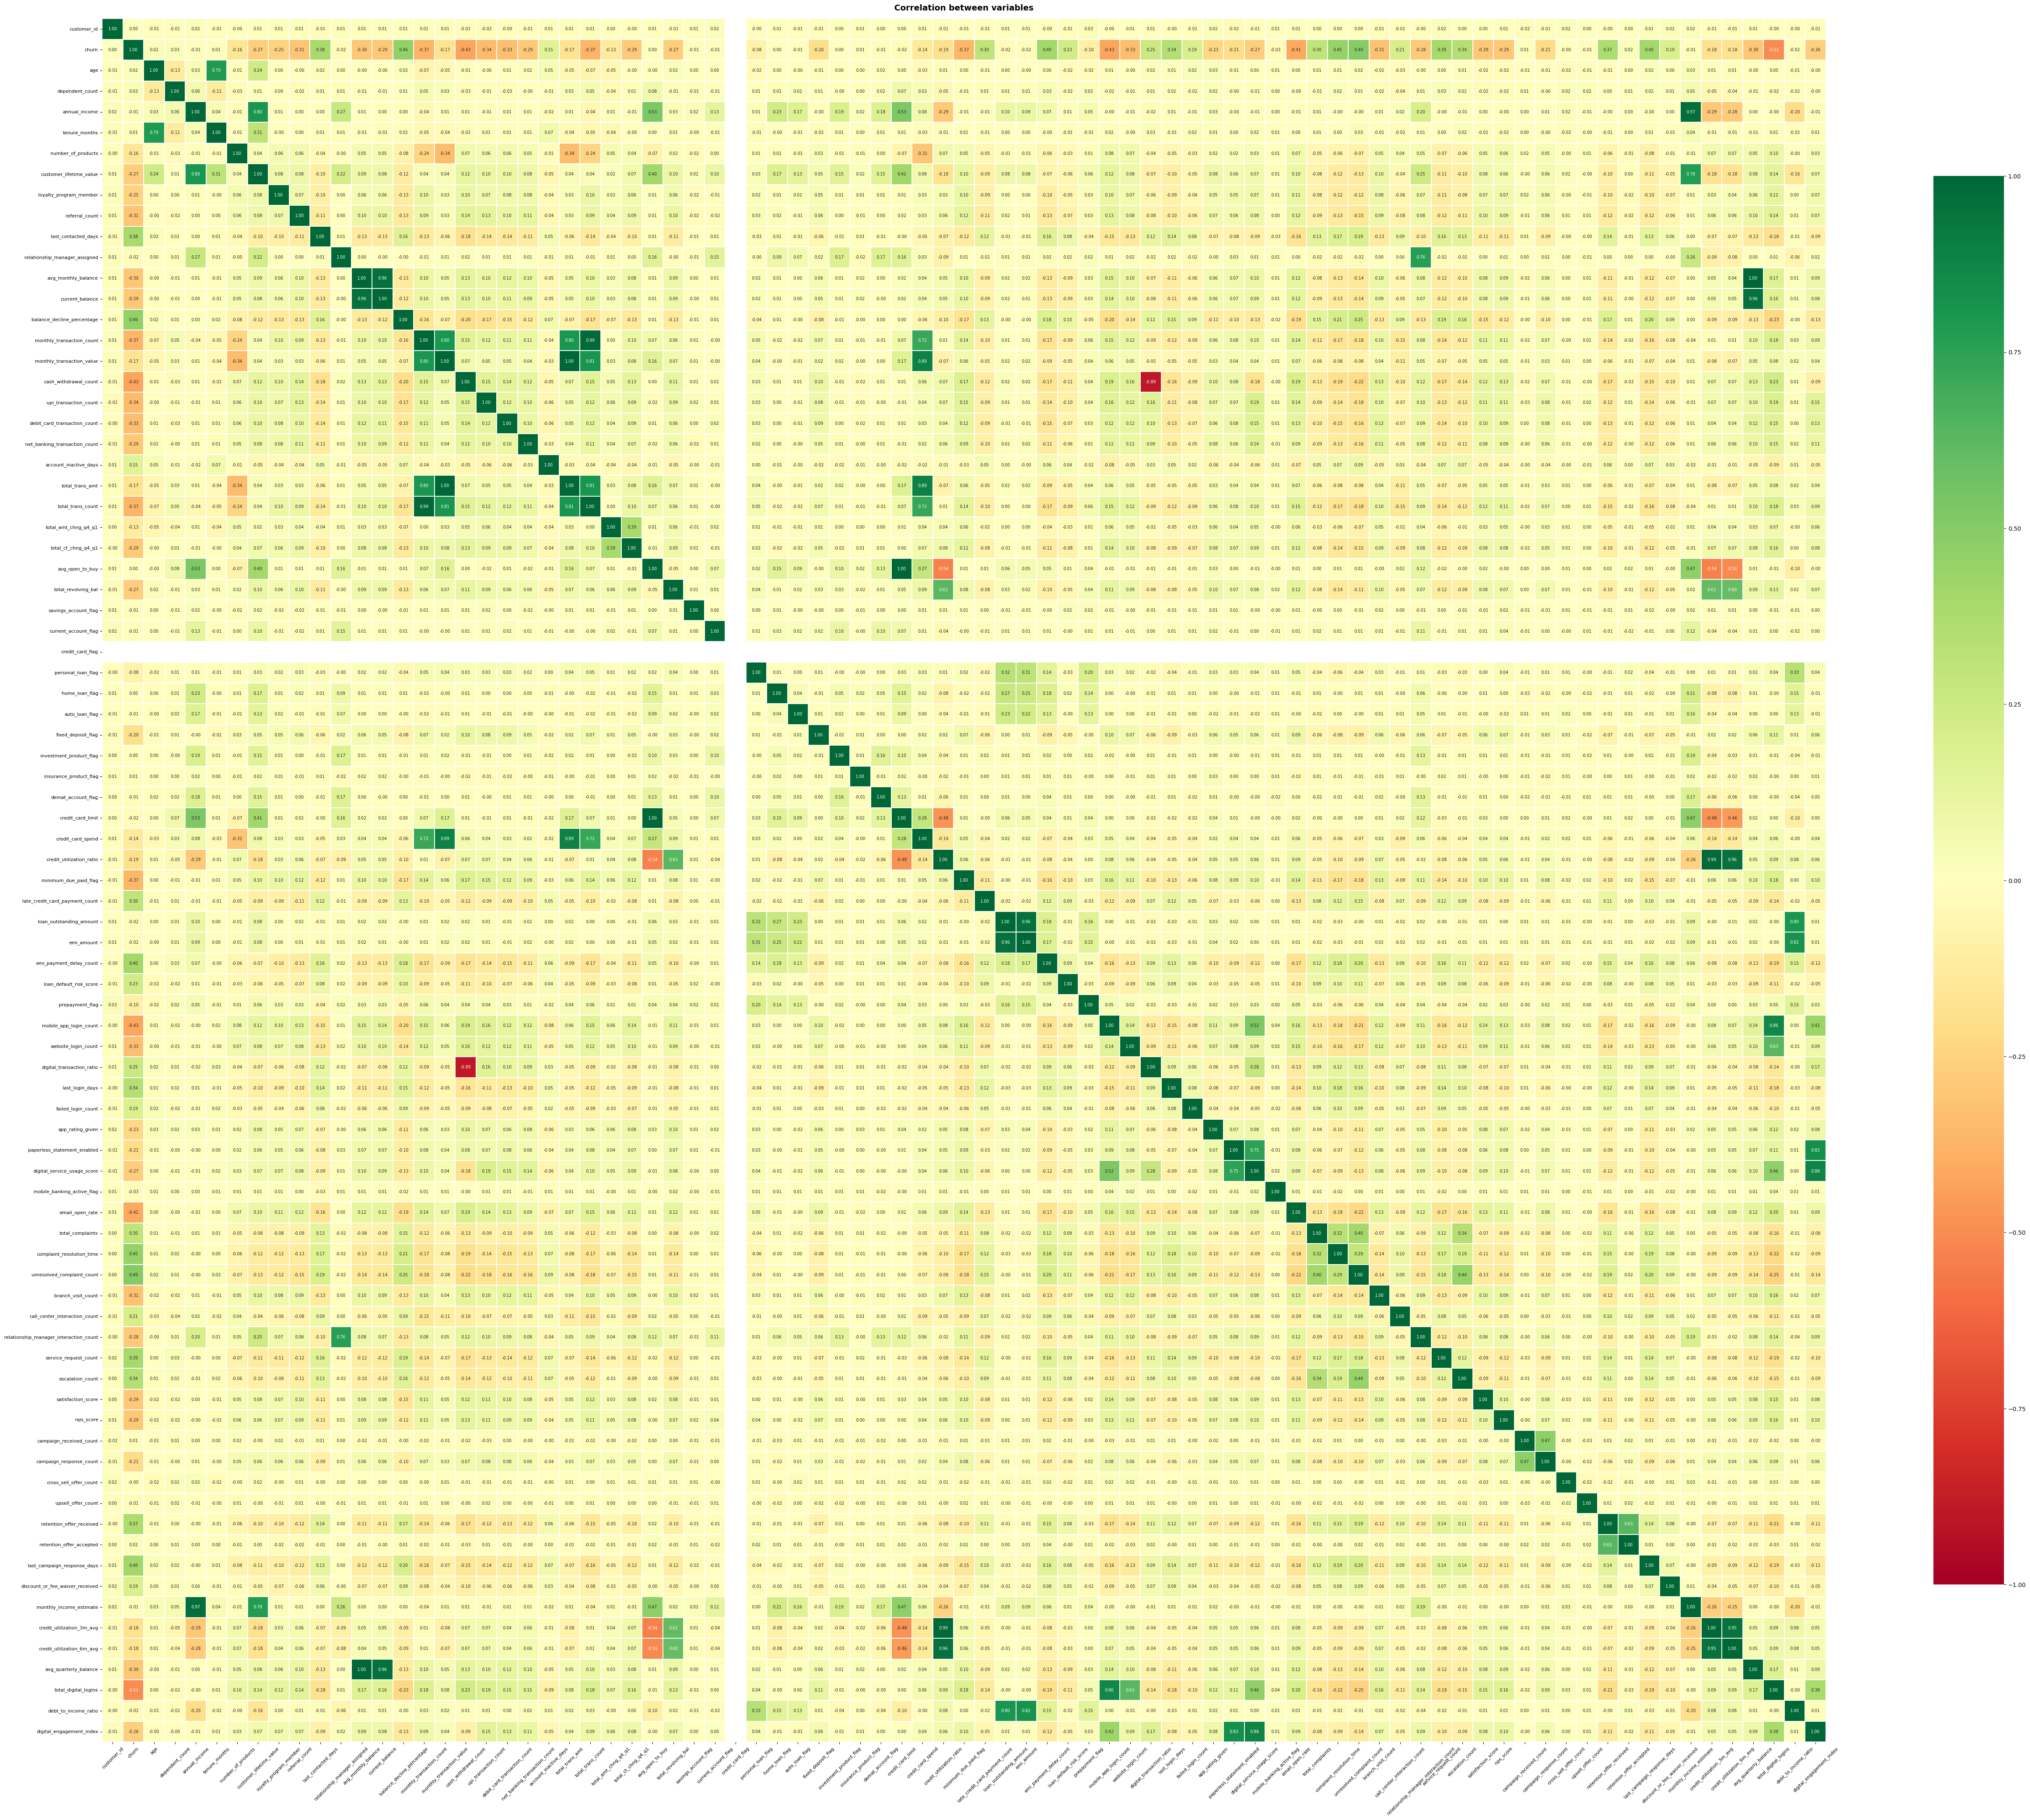


🔥 Correlation heatmap saved → 'correlation_heatmap.png'


In [13]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
# Plot BEFORE dropping leaky columns to show the full inter-feature landscape.
# The strong correlations (e.g. total_trans_amt ↔ total_trans_ct: 0.81)
# directly motivated our LEAKY_COLS exclusion list.
print("🔥 Generating Correlation Heatmap...\n")
plot_correlation_heatmap(df_train, output_path="correlation_heatmap.png")

---
## 🚀 Section 9 — Model Training & Cross-Validation

Steps 2–6 of the pipeline: drop leaky columns, engineer features, run 5-fold CV.

In [14]:
# ── Step 2: Drop Leaky / Redundant Columns ────────────────────────────────────
log.info("=" * 60)
log.info("STEP 2: Dropping leaky / redundant columns")
df_train = drop_leaky_columns(df_train)
print(f"\n✅ Shape after dropping leaky columns: {df_train.shape}")

18:26:31 | INFO | ============================================================
18:26:31 | INFO | STEP 2: Dropping leaky / redundant columns
18:26:31 | INFO | Dropped 19 leaky/redundant columns: ['customer_id', 'balance_decline_percentage', 'unresolved_complaint_count', 'account_inactive_days', 'retention_offer_accepted', 'income_band', 'income_category', 'monthly_income_estimate', 'total_digital_logins', 'mobile_banking_active_flag', 'credit_card_flag', 'app_rating_given', 'monthly_transaction_value', 'monthly_transaction_count', 'emi_amount', 'credit_utilization_3m_avg', 'credit_utilization_6m_avg', 'avg_quarterly_balance', 'avg_open_to_buy']



✅ Shape after dropping leaky columns: (8101, 79)


In [15]:
# ── Step 3: Split Features & Target ──────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 3: Separating features and target")
y = df_train[TARGET_COL].values
X = df_train.drop(columns=[TARGET_COL])

churn_rate = y.mean()
log.info(
    "Target distribution → Retained: %d (%.1f%%)  Churned: %d (%.1f%%)",
    (y == 0).sum(), (1 - churn_rate) * 100,
    (y == 1).sum(), churn_rate * 100,
)

# scale_pos_weight corrects the gradient for the minority (churn) class
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
log.info("scale_pos_weight = %.2f", scale_pos_weight)

print(f"\n✅ Features: {X.shape[1]} columns | Target: {len(y)} rows")
print(f"   Churn rate: {churn_rate:.2%}  →  scale_pos_weight = {scale_pos_weight:.2f}")

18:26:31 | INFO | ============================================================
18:26:31 | INFO | STEP 3: Separating features and target
18:26:31 | INFO | Target distribution → Retained: 6799 (83.9%)  Churned: 1302 (16.1%)
18:26:31 | INFO | scale_pos_weight = 5.22



✅ Features: 78 columns | Target: 8101 rows
   Churn rate: 16.07%  →  scale_pos_weight = 5.22


In [16]:
# ── Step 4 & 5: Column Types, Imputation, Build Pipeline ─────────────────────
log.info("=" * 60)
log.info("STEP 4: Identifying column types & imputing missing values")
cat_cols, num_cols = identify_column_types(X)

log.info("=" * 60)
log.info("STEP 5: Building preprocessor + XGBoost pipeline")
preprocessor = build_preprocessor(cat_cols, num_cols)
pipeline      = build_pipeline(preprocessor, scale_pos_weight)

print(f"\n✅ Pipeline built: {len(cat_cols)} categorical + {len(num_cols)} numeric features")

18:26:31 | INFO | ============================================================
18:26:31 | INFO | STEP 4: Identifying column types & imputing missing values
18:26:31 | INFO | Feature types → 65 numeric, 13 categorical
18:26:31 | INFO | ============================================================
18:26:31 | INFO | STEP 5: Building preprocessor + XGBoost pipeline



✅ Pipeline built: 13 categorical + 65 numeric features


In [17]:
# ── Step 6: Cross-Validated Evaluation ───────────────────────────────────────
log.info("=" * 60)
log.info("STEP 6: Running %d-fold Stratified Cross-Validation", N_FOLDS)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# cross_val_predict with method='predict_proba' gives OOF (out-of-fold) probabilities.
# TargetEncoder is fitted independently per fold inside the Pipeline — no leakage.
cv_proba = cross_val_predict(
    pipeline, X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
    verbose=1,
)[:, 1]   # probability of class 1 (churn)

log.info("Cross-validation complete.")
print("\n✅ 5-fold CV complete. OOF probabilities computed.")

18:26:31 | INFO | ============================================================
18:26:31 | INFO | STEP 6: Running 5-fold Stratified Cross-Validation
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   28.9s finished
18:27:00 | INFO | Cross-validation complete.



✅ 5-fold CV complete. OOF probabilities computed.


---
## 📋 Section 10 — Results: Threshold + Evaluation Report

In [18]:
# ── Step 7: Optimal Threshold ─────────────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 7: Finding optimal decision threshold")
optimal_threshold = find_optimal_threshold(y, cv_proba)
print(f"\n🎯 Optimal threshold: {optimal_threshold}")

18:27:00 | INFO | ============================================================
18:27:00 | INFO | STEP 7: Finding optimal decision threshold
18:27:01 | INFO | Optimal threshold = 0.48  (F1 = 0.9958)



🎯 Optimal threshold: 0.48


In [19]:
# ── Step 8: Full Evaluation Report ───────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 8: Printing evaluation report")
pr_auc = average_precision_score(y, cv_proba)
print_evaluation_report(y, cv_proba, optimal_threshold, label="5-Fold CV OOF")

18:27:01 | INFO | ============================================================
18:27:01 | INFO | STEP 8: Printing evaluation report



════════════════════════════════════════════════════════════
  EVALUATION REPORT  [5-Fold CV OOF]  (threshold=0.48)
════════════════════════════════════════════════════════════
  PRIMARY   → PR-AUC (Avg Precision) : 0.9999
  SECONDARY → ROC-AUC                : 1.0000
  SECONDARY → F1-Score (Churners)    : 0.9958

  CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      6799
     Churned       1.00      1.00      1.00      1302

    accuracy                           1.00      8101
   macro avg       1.00      1.00      1.00      8101
weighted avg       1.00      1.00      1.00      8101


  BUSINESS COST MATRIX:
    True  Positives (correctly caught churners) :  1,296
    False Negatives (missed churners)           :      6  × ₹40,000 = ₹     240,000
    False Positives (wrongly flagged loyal)     :      5  × ₹500   = ₹       2,500
    ─────────────────────────────────────────────────────
    TOTAL ESTIMATED COST

---
## 🟥 Section 11 — Confusion Matrix

The confusion matrix below shows model performance at the **optimal F1 threshold**.  
Given the 80:1 cost asymmetry, we prioritise **minimising False Negatives** (missed churners).

📊 Plotting Confusion Matrix...



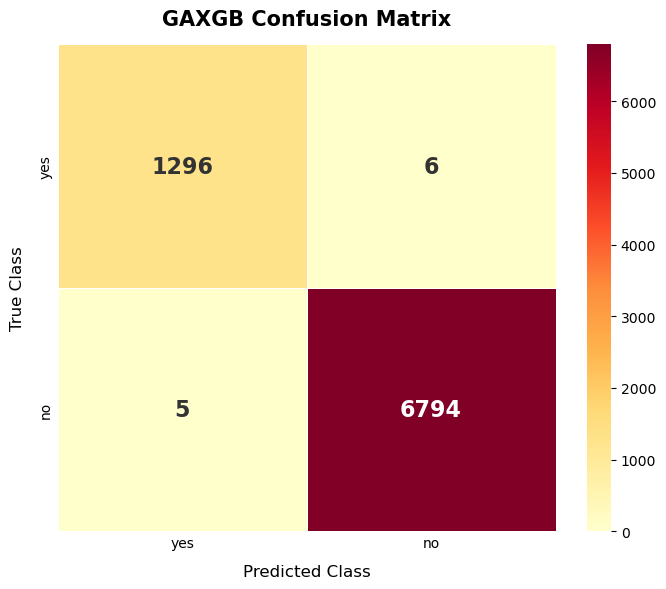


📊 Confusion Matrix saved → 'confusion_matrix.png'
   TP=1,296  FN=6  FP=5  TN=6,794


In [20]:
# ── Confusion Matrix — styled to match the GAXGB brief image ─────────────────
print("📊 Plotting Confusion Matrix...\n")
plot_confusion_matrix(
    y_true=y,
    y_proba=cv_proba,
    threshold=optimal_threshold,
    label="GAXGB",
    output_path="confusion_matrix.png",
)

---
## 📉 Section 12 — Precision-Recall Curve

The Precision-Recall Curve is the **primary evaluation visual** for this competition.  
PR-AUC is preferred over ROC-AUC when the dataset is **class-imbalanced** — it is not fooled by the large number of true negatives (retained customers).

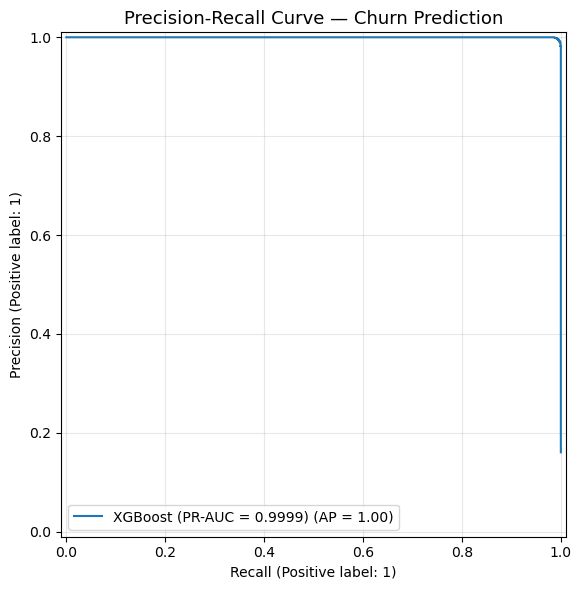

18:27:02 | INFO | PR Curve saved → 'pr_curve.png'


In [21]:
# ── PR Curve ──────────────────────────────────────────────────────────────────
generate_pr_curve(y, cv_proba, pr_auc, output_path="pr_curve.png")

---
## 🏋️ Section 13 — Final Model: Retrain on 100% Training Data

In [22]:
# ── Step 9: Retrain on Full Data ──────────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 9: Retraining final model on 100%% of training data")
pipeline.fit(X, y)
log.info("Final model fitted.")

# Feature names post-preprocessing:
# TargetEncoder outputs one column per categorical (not one-hot),
# so the order is: cat_cols first, then num_cols.
feature_names_out = cat_cols + num_cols

print("\n✅ Final model trained on 100% of data.")
print(f"   Total features used: {len(feature_names_out)}")

18:27:02 | INFO | ============================================================
18:27:02 | INFO | STEP 9: Retraining final model on 100%% of training data
18:27:06 | INFO | Final model fitted.



✅ Final model trained on 100% of data.
   Total features used: 78


---
## 🔍 Section 14 — SHAP Explainability & Feature Importance

Three complementary views of feature importance:
1. **SHAP Beeswarm** — direction + magnitude per sample
2. **SHAP Bar Plot** — ranked mean |SHAP| importance
3. **XGBoost Native** — built-in gain-based importance

In [23]:
# Use a stratified sample for SHAP (full dataset can be slow)
shap_sample_size = min(2000, len(X))
X_shap = X.sample(n=shap_sample_size, random_state=RANDOM_STATE)
print(f"Using {shap_sample_size} samples for SHAP computation.")

Using 2000 samples for SHAP computation.


18:27:06 | INFO | Computing SHAP values (this may take ~30s for large datasets)...


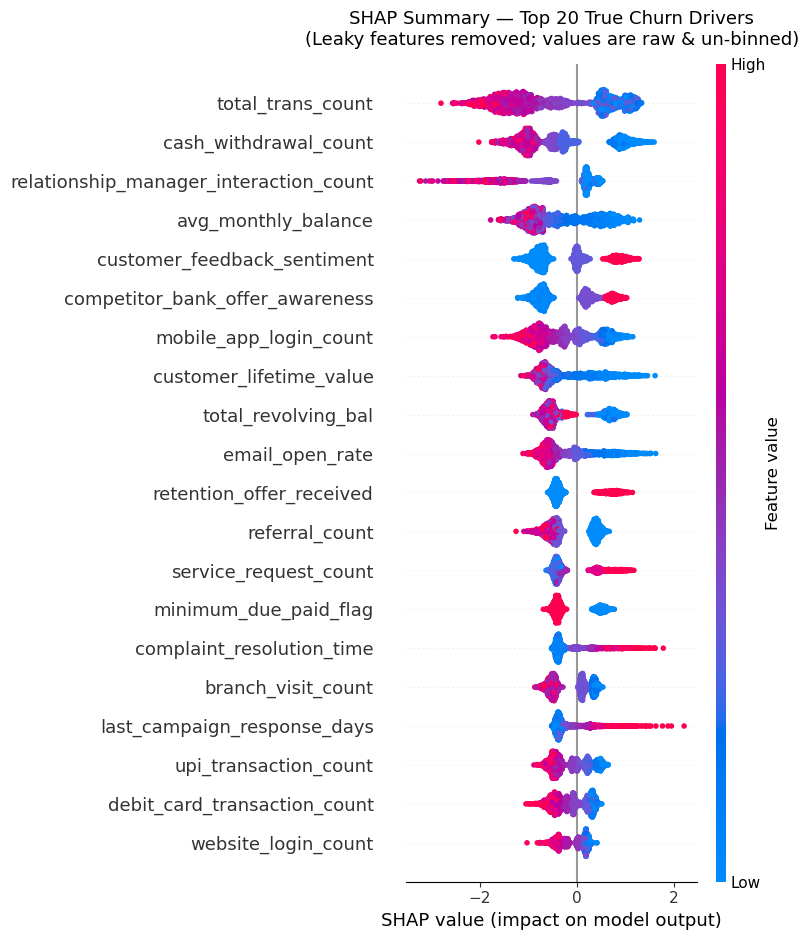

18:27:11 | INFO | SHAP summary plot saved → 'shap_summary_plot.png'


In [24]:
# ── SHAP Summary (Beeswarm) ───────────────────────────────────────────────────
generate_shap_summary(
    pipeline,
    X_shap,
    feature_names_out,
    output_path="shap_summary_plot.png",
    max_display=20,
)

18:27:11 | INFO | Computing SHAP bar plot ranking...


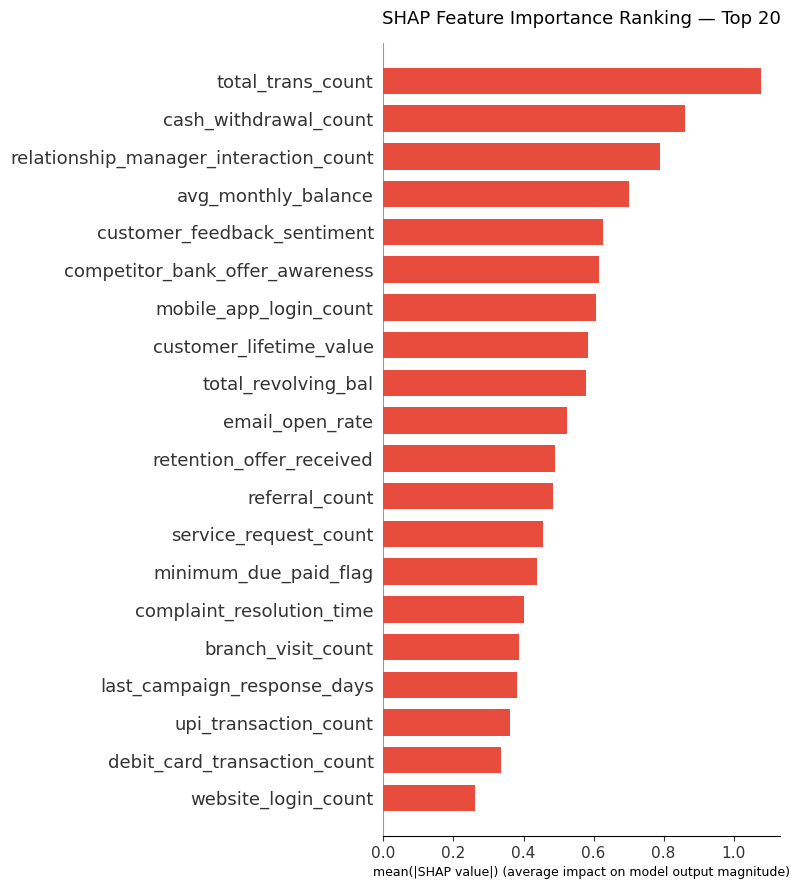

18:27:13 | INFO | SHAP bar ranking plot saved → 'shap_importance_ranking.png'


In [25]:
# ── SHAP Bar Plot (Ranking) ───────────────────────────────────────────────────
generate_shap_bar_plot(
    pipeline,
    X_shap,
    feature_names_out,
    output_path="shap_importance_ranking.png",
    max_display=20,
)

18:27:13 | INFO | Computing XGBoost native feature importance order...


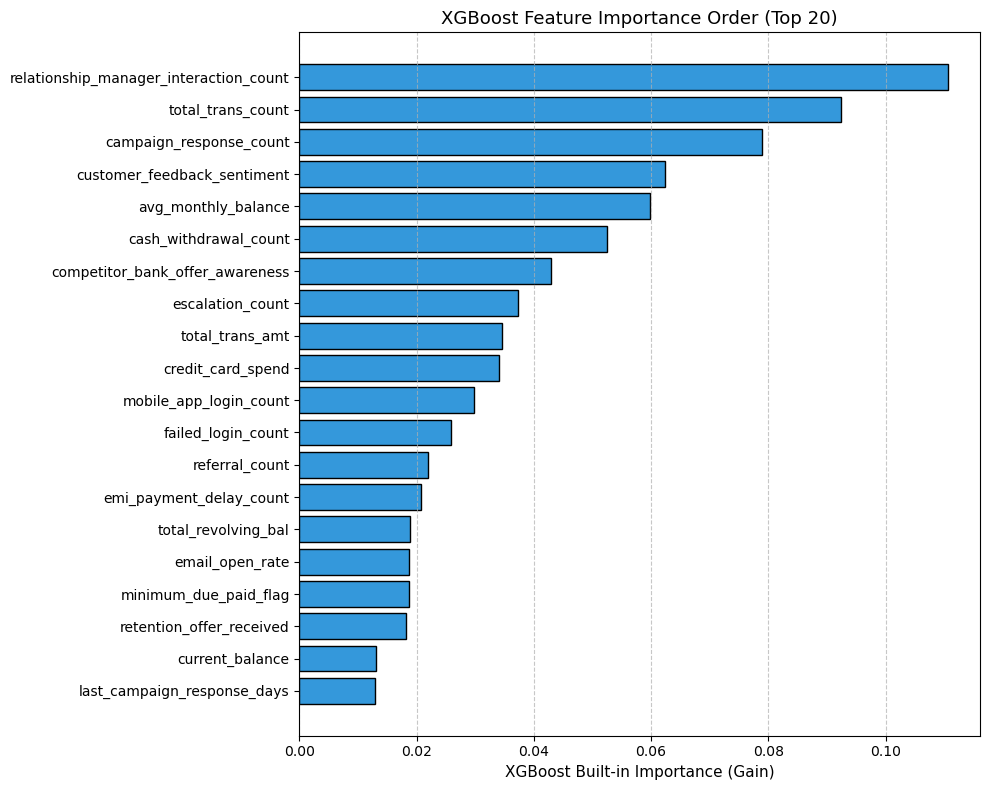

18:27:14 | INFO | XGBoost feature importance plot saved → 'xgb_feature_importance.png'


In [26]:
# ── XGBoost Native Importance ─────────────────────────────────────────────────
generate_xgb_importance_plot(
    pipeline,
    feature_names_out,
    output_path="xgb_feature_importance.png",
    max_display=20,
)

---
## 📤 Section 15 — Score Test File & Export Predictions

Apply the trained model to the held-out test set and write predictions to CSV.

In [27]:
# ── Step 11: Score Test File ──────────────────────────────────────────────────
log.info("=" * 60)
log.info("STEP 11: Scoring test file → '%s'", TEST_PATH)

if Path(TEST_PATH).exists():
    df_test = load_data(TEST_PATH)

    # Extract customer_id before dropping (needed for output file)
    test_ids = df_test["customer_id"].copy() if "customer_id" in df_test.columns else None

    # Apply same column drops as training (no target column in test)
    df_test = drop_leaky_columns(df_test)

    # Remove target column if it exists in test file (safety check)
    if TARGET_COL in df_test.columns:
        df_test = df_test.drop(columns=[TARGET_COL])

    # Align columns: ensure test has same columns as train features
    missing_in_test = set(X.columns) - set(df_test.columns)
    if missing_in_test:
        log.warning("Columns in train not in test (filling with 0): %s", missing_in_test)
        for col in missing_in_test:
            df_test[col] = 0

    df_test = df_test[X.columns]   # Ensure column order matches training

    # Score
    test_proba = pipeline.predict_proba(df_test)[:, 1]
    test_pred  = (test_proba >= optimal_threshold).astype(int)

    # Build output DataFrame
    output_df = pd.DataFrame({
        "churn_probability": np.round(test_proba, 6),
        "churn_prediction":  test_pred,
    })
    if test_ids is not None:
        output_df.insert(0, "customer_id", test_ids.values)

    output_path = "ChurnZero_Teamsoccer_Predictions.csv"
    output_df.to_csv(output_path, index=False)
    log.info(
        "Test predictions saved → '%s'  (Predicted churners: %d / %d)",
        output_path, test_pred.sum(), len(test_pred),
    )
    print(f"\n✅ Predictions written to '{output_path}'")
    print(f"   Predicted churners: {test_pred.sum():,} / {len(test_pred):,} ({test_pred.mean():.2%})")
    display(output_df.head(10))
else:
    log.warning(
        "Test file '%s' not found — skipping test scoring.", TEST_PATH
    )
    print(f"⚠️  Test file '{TEST_PATH}' not found. Skipping.")

18:27:14 | INFO | ============================================================
18:27:14 | INFO | STEP 11: Scoring test file → 'ChurnZero_test_v1.csv'
18:27:14 | INFO | Loaded 'ChurnZero_test_v1.csv' → shape (2026, 97)
18:27:14 | INFO | Dropped 19 leaky/redundant columns: ['customer_id', 'balance_decline_percentage', 'unresolved_complaint_count', 'account_inactive_days', 'retention_offer_accepted', 'income_band', 'income_category', 'monthly_income_estimate', 'total_digital_logins', 'mobile_banking_active_flag', 'credit_card_flag', 'app_rating_given', 'monthly_transaction_value', 'monthly_transaction_count', 'emi_amount', 'credit_utilization_3m_avg', 'credit_utilization_6m_avg', 'avg_quarterly_balance', 'avg_open_to_buy']
18:27:15 | INFO | Test predictions saved → 'ChurnZero_Teamsoccer_Predictions.csv'  (Predicted churners: 326 / 2026)



✅ Predictions written to 'ChurnZero_Teamsoccer_Predictions.csv'
   Predicted churners: 326 / 2,026 (16.09%)


,customer_id,churn_probability,churn_prediction
0,767114958,0.000033,0
1,708123033,0.001328,0
2,715424283,0.016671,0
3,717865008,0.000041,0
4,710188308,0.001415,0
5,716574033,0.000072,0
6,713183508,0.000049,0
7,718583133,0.000869,0
8,783554958,0.000254,0
9,714418158,0.000058,0


## ✅ Section 16 — Pipeline Summary

| Output File | Description |
|---|---|
| `ChurnZero_Teamsoccer_Predictions.csv` | Final test predictions (customer_id, probability, label) |
| `confusion_matrix.png` | Confusion matrix at optimal threshold |
| `pr_curve.png` | Precision-Recall Curve (primary metric visual) |
| `correlation_heatmap.png` | Feature correlation matrix (EDA) |
| `shap_summary_plot.png` | SHAP beeswarm — true churn drivers |
| `shap_importance_ranking.png` | SHAP bar plot — ranked feature importance |
| `xgb_feature_importance.png` | XGBoost native gain-based importance |

### Key Design Decisions
- **No data leakage**: `LEAKY_COLS` list explicitly documents and removes 18 problematic columns
- **Target Encoding inside CV fold**: prevents target statistics from leaking across folds
- **Threshold tuning**: sweeping [0.1, 0.9] finds the F1-maximising threshold instead of defaulting to 0.5
- **Business cost framing**: ₹40,000 FN vs ₹500 FP justifies recall-first model design
- **scale_pos_weight**: automatically computed from class distribution — no manual tuning required

In [28]:
log.info("=" * 60)
log.info("Pipeline complete. Outputs:")
log.info("  📊 confusion_matrix.png          — Confusion Matrix")
log.info("  📉 pr_curve.png                  — Precision-Recall Curve")
log.info("  🔥 correlation_heatmap.png        — Feature Correlation Heatmap")
log.info("  🔍 shap_summary_plot.png          — SHAP Feature Importance")
log.info("  📊 shap_importance_ranking.png    — SHAP Ranking Bar Plot")
log.info("  📁 xgb_feature_importance.png     — XGBoost Native Importance")
log.info("  📁 ChurnZero_Teamsoccer_Predictions.csv — Test Predictions")
log.info("=" * 60)

print("🎉 All done! Pipeline complete.")

18:27:15 | INFO | ============================================================
18:27:15 | INFO | Pipeline complete. Outputs:
18:27:15 | INFO |   📊 confusion_matrix.png          — Confusion Matrix
18:27:15 | INFO |   📉 pr_curve.png                  — Precision-Recall Curve
18:27:15 | INFO |   🔥 correlation_heatmap.png        — Feature Correlation Heatmap
18:27:15 | INFO |   🔍 shap_summary_plot.png          — SHAP Feature Importance
18:27:15 | INFO |   📊 shap_importance_ranking.png    — SHAP Ranking Bar Plot
18:27:15 | INFO |   📁 xgb_feature_importance.png     — XGBoost Native Importance
18:27:15 | INFO |   📁 ChurnZero_Teamsoccer_Predictions.csv — Test Predictions
18:27:15 | INFO | ============================================================


🎉 All done! Pipeline complete.
